--- Experiment 4: Decision Tree & Random Forest ---
Enter number of trees for Forest [default: 10]: 10

Discretizing attributes (Bins=5)...

--- Task 1 & 2: Decision Tree (Depth=4, Pruning Threshold=0.01) ---
Decision Tree Accuracy: 0.8888888888888888
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       0.79      0.85      0.81        13
           2       0.91      0.77      0.83        13

    accuracy                           0.89        45
   macro avg       0.88      0.87      0.87        45
weighted avg       0.89      0.89      0.89        45


--- Task 3: Generating Decision Boundary Plots ---
(Close the plot window to continue)


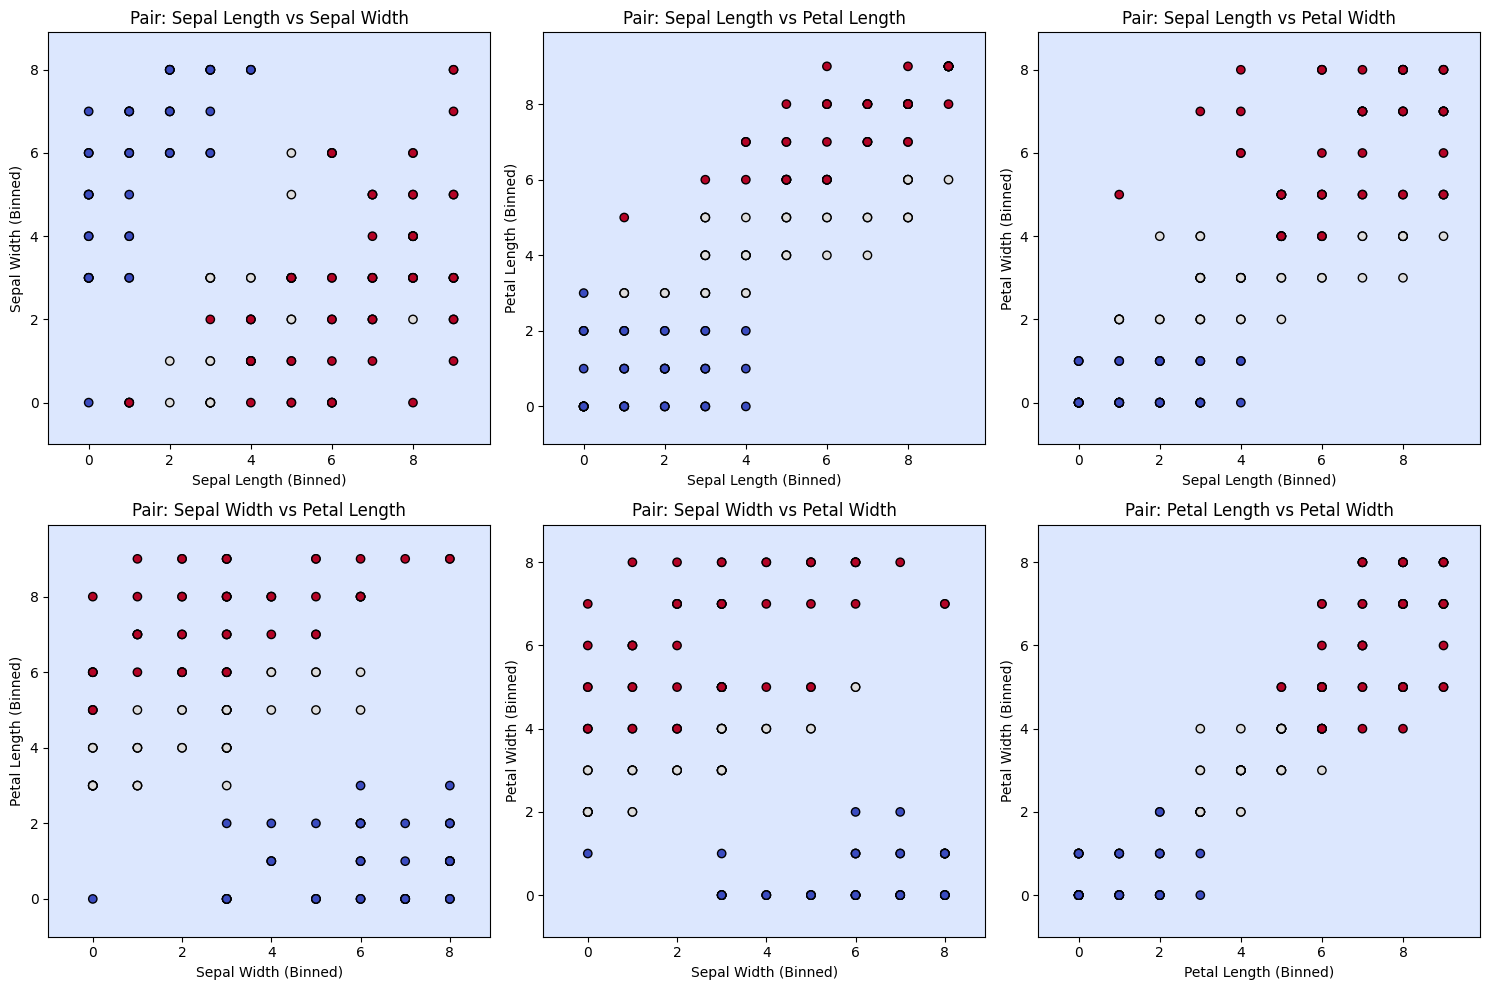


--- Task 4 & 5: Random Forest & Partitioning Comparison ---

Training Random Forest using 'horizontal' partitioning...
Accuracy (horizontal): 0.9333

Training Random Forest using 'vertical' partitioning...
Accuracy (vertical): 0.8667

Training Random Forest using 'combined' partitioning...
Accuracy (combined): 0.9556

--- Summary Comparison  ---
Technique            | Accuracy  
-----------------------------------
Horizontal           | 0.9333
Vertical             | 0.8667
Combined             | 0.9556


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# discretization

def discretize_data(X, n_bins=5):
    """
    Discretizes continuous attribute values into bins.
    Required by the lab manual for attribute selection.
    """
    X_discrete = X.copy()
    for col in range(X.shape[1]):
        # Use pandas qcut for quantile-based discretization
        # This handles the continuous nature of Iris data
        try:
            X_discrete[:, col] = pd.qcut(X[:, col], q=n_bins, labels=False, duplicates='drop')
        except ValueError:
            # Fallback if too many duplicates
            X_discrete[:, col] = pd.cut(X[:, col], bins=n_bins, labels=False)
    return X_discrete

def calculate_entropy(y):
    """Calculates Shannon Entropy for a label vector y."""
    class_labels, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    entropy = -np.sum(probabilities * np.log2(probabilities + 1e-9)) # +1e-9 for numerical stability
    return entropy

def calculate_information_gain(X_col, y):
    """
    Calculates Information Gain for a specific attribute.
    IG = Entropy(Parent) - Weighted_Avg_Entropy(Children) [cite: 6]
    """
    parent_entropy = calculate_entropy(y)

    values, counts = np.unique(X_col, return_counts=True)
    weighted_child_entropy = 0

    for v, count in zip(values, counts):
        child_y = y[X_col == v]
        weighted_child_entropy += (count / len(y)) * calculate_entropy(child_y)

    return parent_entropy - weighted_child_entropy

# ---------------------------------------------------------
# 1 & 2: DECISION TREE CLASS FROM SCRATCH
# ---------------------------------------------------------

class Node:
    def __init__(self, feature=None, value=None, result=None, children=None):
        self.feature = feature   # Index of the attribute used for splitting
        self.value = value       # Value of the attribute (for discrete branches)
        self.result = result     # Class label (if leaf node)
        self.children = children # Dictionary of {feature_value: Node}

class CustomDecisionTree:
    def __init__(self, max_depth=None, error_threshold=0.0):
        """
        Init with max_depth  and error_threshold for pruning[cite: 8].
        """
        self.max_depth = max_depth
        self.error_threshold = error_threshold
        self.root = None

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        unique_classes = np.unique(y)

        # Stopping Criteria:
        # 1. Pure Node
        if len(unique_classes) == 1:
            return Node(result=unique_classes[0])

        # 2. Max Depth Reached
        if self.max_depth is not None and depth >= self.max_depth:
            return Node(result=self._most_common_label(y))

        # 3. No features left (though rare in this implementation due to discrete reuse) or tiny sample
        if num_samples < 2:
            return Node(result=self._most_common_label(y))

        # Select Best Attribute based on Information Gain [cite: 6]
        best_gain = -1
        best_feature_idx = None

        for idx in range(num_features):
            gain = calculate_information_gain(X[:, idx], y)
            if gain > best_gain:
                best_gain = gain
                best_feature_idx = idx

        # Top-Down Pruning Mechanism [cite: 8]
        # If the Information Gain is negligible (indicating error reduction is below threshold)
        if best_gain <= self.error_threshold:
             return Node(result=self._most_common_label(y))

        # Create Tree Structure
        node = Node(feature=best_feature_idx, children={})

        # Split data based on discrete values of the best feature
        unique_values = np.unique(X[:, best_feature_idx])

        for val in unique_values:
            # Partition the data
            mask = X[:, best_feature_idx] == val
            X_subset = X[mask]
            y_subset = y[mask]

            if len(y_subset) == 0:
                node.children[val] = Node(result=self._most_common_label(y))
            else:
                node.children[val] = self._build_tree(X_subset, y_subset, depth + 1)

        return node

    def _most_common_label(self, y):
        return np.bincount(y).argmax()

    def predict(self, X):
        predictions = [self._predict_single(sample, self.root) for sample in X]
        return np.array(predictions)

    def _predict_single(self, sample, node):
        if node.result is not None:
            return node.result

        val = sample[node.feature]

        # Handle unseen values in test set by returning most common (simple fallback)
        if val in node.children:
            return self._predict_single(sample, node.children[val])
        else:
            # If path doesn't exist (e.g., specific bin not in training), return closest guess
            # Ideally, we would track majority class at this node
            return 0

# ---------------------------------------------------------
# 4: RANDOM FOREST FROM SCRATCH
# ---------------------------------------------------------

class CustomRandomForest:
    def __init__(self, n_trees=10, max_depth=5, technique='combined'):
        """
        n_trees: Number of trees [cite: 11]
        technique: 'horizontal' (bagging), 'vertical' (feature subset), or 'combined'
        """
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.technique = technique
        self.trees = []
        self.feature_subsets = [] # To track which features each tree used (for vertical partitioning)

    def fit(self, X, y):
        self.trees = []
        n_samples, n_features = X.shape

        for _ in range(self.n_trees):
            X_sample, y_sample = X.copy(), y.copy()
            features_idx = np.arange(n_features)

            # Horizontal Partitioning (Bootstrap Aggregation / Bagging)
            if self.technique in ['horizontal', 'combined']:
                indices = np.random.choice(n_samples, n_samples, replace=True)
                X_sample = X_sample[indices]
                y_sample = y_sample[indices]

            # Vertical Partitioning (Random Subspace Method)
            if self.technique in ['vertical', 'combined']:
                # Select random subset of features (e.g., sqrt of total features)
                n_subset = max(1, int(np.sqrt(n_features)))
                features_idx = np.random.choice(n_features, n_subset, replace=False)
                X_sample = X_sample[:, features_idx]

            # Train Tree
            tree = CustomDecisionTree(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)

            self.trees.append(tree)
            self.feature_subsets.append(features_idx)

    def predict(self, X):
        tree_preds = []
        for i, tree in enumerate(self.trees):
            # If vertical partitioning was used, filter X for specific tree
            features_idx = self.feature_subsets[i]
            if self.technique in ['vertical', 'combined']:
                 pred = tree.predict(X[:, features_idx])
            else:
                 pred = tree.predict(X)
            tree_preds.append(pred)

        tree_preds = np.array(tree_preds).T # Shape: (n_samples, n_trees)

        # Majority Voting
        final_preds = []
        for row in tree_preds:
            final_preds.append(np.bincount(row).argmax())

        return np.array(final_preds)

# ---------------------------------------------------------
# 3: VISUALIZATION
# ---------------------------------------------------------

def plot_decision_boundaries(X, y, depth):
    """
    Generates scatter plot of decision boundaries considering every pair of attributes.
    """
    feature_names = ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width']
    pairs = list(itertools.combinations(range(4), 2))

    plt.figure(figsize=(15, 10))

    for i, (f1, f2) in enumerate(pairs):
        # We must re-train a 2D model for the visualization to make sense
        # extracting only the two current features
        X_pair = X[:, [f1, f2]]

        # Discretize just this pair
        X_pair_disc = discretize_data(X_pair, n_bins=10)

        clf = CustomDecisionTree(max_depth=depth)
        clf.fit(X_pair_disc, y)

        # Create Meshgrid
        x_min, x_max = X_pair_disc[:, 0].min() - 1, X_pair_disc[:, 0].max() + 1
        y_min, y_max = X_pair_disc[:, 1].min() - 1, X_pair_disc[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                             np.arange(y_min, y_max, 0.1))

        # Predict mesh points
        # Flatten and predict
        mesh_points = np.c_[xx.ravel(), yy.ravel()]
        # Discretize mesh points similarly to training data (rough approximation for plot)
        mesh_preds = clf.predict(mesh_points)
        mesh_preds = mesh_preds.reshape(xx.shape)

        plt.subplot(2, 3, i + 1)
        plt.contourf(xx, yy, mesh_preds, alpha=0.3, cmap=plt.cm.coolwarm)
        plt.scatter(X_pair_disc[:, 0], X_pair_disc[:, 1], c=y, edgecolors='k', cmap=plt.cm.coolwarm)
        plt.xlabel(f"{feature_names[f1]} (Binned)")
        plt.ylabel(f"{feature_names[f2]} (Binned)")
        plt.title(f"Pair: {feature_names[f1]} vs {feature_names[f2]}")

    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# MAIN EXECUTION
# ---------------------------------------------------------

def main():
    print("--- Experiment 4: Decision Tree & Random Forest ---")

    # 0. Load Data [cite: 4]
    iris = load_iris()
    X_raw, y = iris.data, iris.target

    # 1. User Inputs
    try:
        u_depth = int(input("Enter max depth for the tree [default: 3]: ") or 3) #
        u_trees = int(input("Enter number of trees for Forest [default: 10]: ") or 10) # [cite: 11]
    except ValueError:
        u_depth = 3
        u_trees = 10
        print("Invalid input. Using defaults.")

    # 2. Preprocessing: Discretization
    print(f"\nDiscretizing attributes (Bins=5)...")
    X_disc = discretize_data(X_raw, n_bins=5)

    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(X_disc, y, test_size=0.3, random_state=42)

    # 3. Task 1 & 2: Single Decision Tree
    print(f"\n--- Task 1 & 2: Decision Tree (Depth={u_depth}, Pruning Threshold=0.01) ---")
    dt = CustomDecisionTree(max_depth=u_depth, error_threshold=0.01) # error_threshold implements pruning [cite: 8]
    dt.fit(X_train, y_train)
    y_pred_dt = dt.predict(X_test)
    print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
    print(classification_report(y_test, y_pred_dt))

    # 4. Task 3: Visualization
    print("\n--- Task 3: Generating Decision Boundary Plots ---")
    print("(Close the plot window to continue)")
    plot_decision_boundaries(X_raw, y, u_depth)

    # 5. Task 4 & 5: Random Forest & Partitioning Comparison
    print("\n--- Task 4 & 5: Random Forest & Partitioning Comparison ---")

    modes = ['horizontal', 'vertical', 'combined']
    results = {}

    for mode in modes:
        print(f"\nTraining Random Forest using '{mode}' partitioning...")
        rf = CustomRandomForest(n_trees=u_trees, max_depth=u_depth, technique=mode)
        rf.fit(X_train, y_train)
        y_pred_rf = rf.predict(X_test)
        acc = accuracy_score(y_test, y_pred_rf)
        results[mode] = acc
        print(f"Accuracy ({mode}): {acc:.4f}")

    print("\n--- Summary Comparison  ---")
    print(f"{'Technique':<20} | {'Accuracy':<10}")
    print("-" * 35)
    for mode, acc in results.items():
        print(f"{mode.capitalize():<20} | {acc:.4f}")

if __name__ == "__main__":
    main()